In [36]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import  ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

df = pd.read_csv(r'../../Datasets/student_dropout.csv')

df = df[['Age', 'Study_Hours_per_Day', 'Attendance_Rate', 'CGPA', 'Stress_Index', 'Dropout']]



df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean(), inplace=True)
df['Stress_Index'].fillna(df['Stress_Index'].mean(), inplace=True)

C:\Users\Muhammad Awais Raza\AppData\Local\Temp\ipykernel_18624\2746106529.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean(), inplace=True)
C:\Users\Muhammad Awais Raza\AppData\Local\Temp\ipykernel_18624\2746106529.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on 

In [37]:
df

,Age,Study_Hours_per_Day,Attendance_Rate,CGPA,Stress_Index,Dropout
0,22.1,3.360000,86.1,0.90,5.500000,0
1,20.7,4.300000,68.0,1.19,6.800000,1
2,22.4,4.400000,70.9,1.32,5.500000,0
3,24.4,4.014592,82.2,1.77,5.507147,1
4,20.5,4.190000,75.7,0.87,7.000000,0
...,...,...,...,...,...,...
9995,23.9,4.620000,92.0,0.97,5.500000,0
9996,17.0,2.870000,75.2,3.09,6.700000,1
9997,19.4,4.730000,74.9,3.43,3.500000,0
9998,22.1,5.850000,74.2,3.34,6.200000,0


In [84]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Dropout']), df['Dropout'], test_size=0.3, random_state=False)

X_train_df = pd.DataFrame(X_train, columns=['Age',	'Study_Hours_per_Day',	'Attendance_Rate',	'CGPA',	'Stress_Index'])

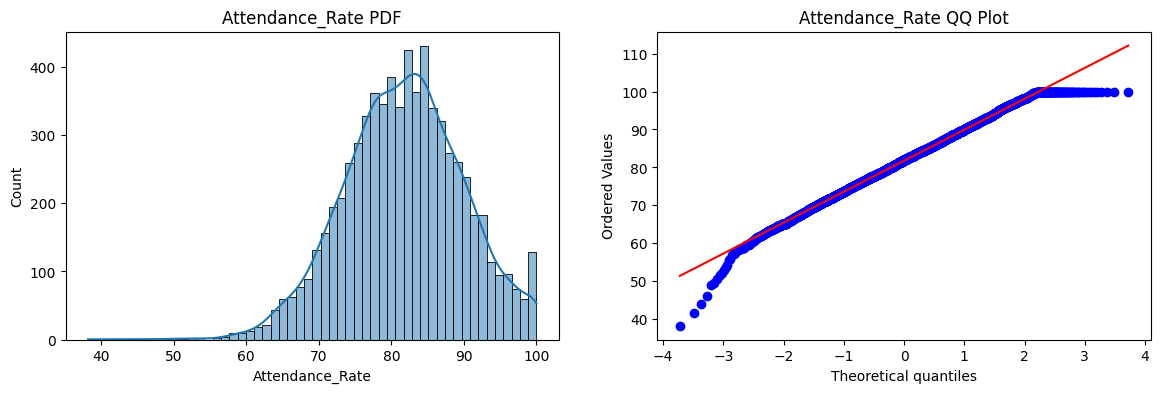

In [85]:
plt.figure(figsize=(14, 4))

# Left plot: histogram / PDF
plt.subplot(121)
sns.histplot(X_train_df['Attendance_Rate'], kde=True)  # kde=True adds PDF
plt.title('Attendance_Rate PDF')

# Right plot: Q-Q plot
plt.subplot(122)
stats.probplot(X_train_df['Attendance_Rate'], dist='norm', plot=plt)
plt.title('Attendance_Rate QQ Plot')

plt.show()


# left skewed: Attendance rate, CGPA
# right skewed: Age

In [86]:
column_transformer = ColumnTransformer([('log', FunctionTransformer(func=np.log1p), ['Age']),
                                        ('square', FunctionTransformer(func=lambda x : x), ['Attendance_Rate', 'CGPA'])], remainder='passthrough')

Without transformation, accuracy

In [87]:
linear_model = LogisticRegression()
tree_model = DecisionTreeClassifier()


linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)


linear_y_pred = linear_model.predict(X_test)
tree_y_pred = tree_model.predict(X_test)

print('Linear accuracy: ', accuracy_score(linear_y_pred, y_test))
print('Tree accuracy: ', accuracy_score(tree_y_pred, y_test))

Linear accuracy:  0.8003333333333333
Tree accuracy:  0.7216666666666667


with transformation, accuracy

In [91]:
X_train_transformed = column_transformer.fit_transform(X_train)
X_test_transformed = column_transformer.transform(X_test)

X_train_tdf = pd.DataFrame(X_train_transformed, columns=['Age', 'Attendance_Rate','CGPA','Study_Hours_per_Day',	'Stress_Index'])

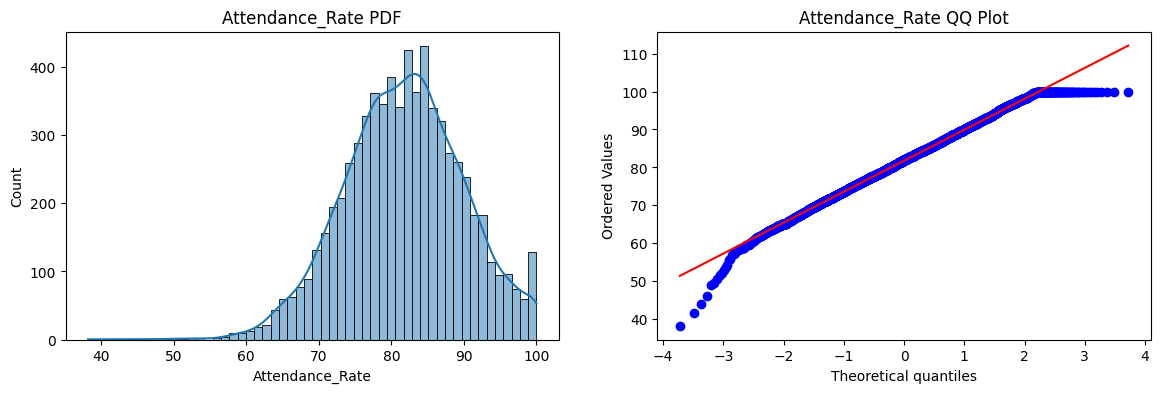

In [92]:
plt.figure(figsize=(14, 4))

plt.subplot(121)
sns.histplot(X_train_tdf['Attendance_Rate'], kde=True)
plt.title('Attendance_Rate PDF')

# Right plot: Q-Q plot
plt.subplot(122)
stats.probplot(X_train_tdf['Attendance_Rate'], dist='norm', plot=plt)
plt.title('Attendance_Rate QQ Plot')

plt.show()

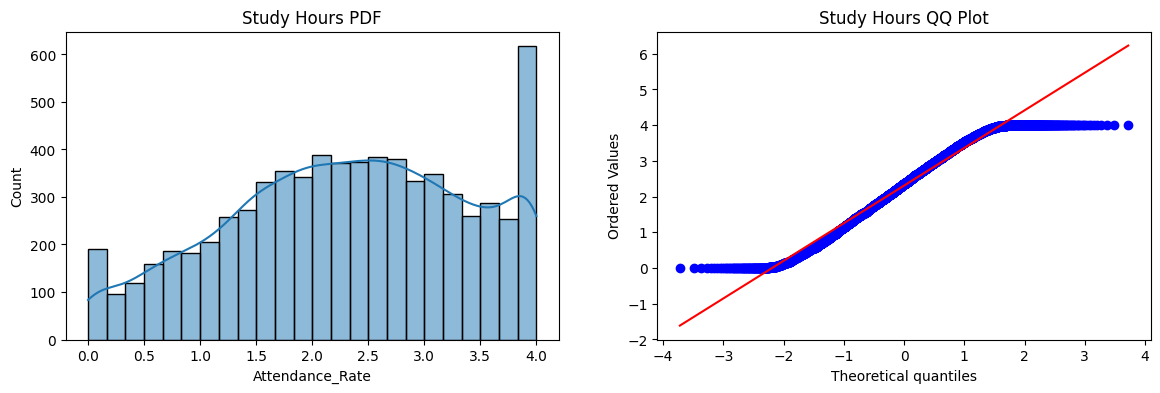

In [79]:
plt.figure(figsize=(14, 4))

plt.subplot(121)
sns.histplot(X_train_tdf['Attendance_Rate'], kde=True)
plt.title('Attendance_Rate PDF')

# Right plot: Q-Q plot
plt.subplot(122)
stats.probplot(X_train_tdf['Attendance_Rate'], dist='norm', plot=plt)
plt.title('Attendance_Rate QQ Plot')

plt.show()

In [44]:
linear_model = LogisticRegression()
tree_model = DecisionTreeClassifier()


linear_model.fit(X_train_transformed, y_train)
tree_model.fit(X_train_transformed, y_train)


linear_y_pred_transformed = linear_model.predict(X_test_transformed)
tree_y_pred_transformed  = tree_model.predict(X_test_transformed)

print('Linear accuracy: ', accuracy_score(linear_y_pred_transformed, y_test))
print('Tree accuracy: ', accuracy_score(tree_y_pred_transformed, y_test))

Linear accuracy:  0.7986666666666666
Tree accuracy:  0.7066666666666667


All values equal: False
Max difference: 97.10962824210384


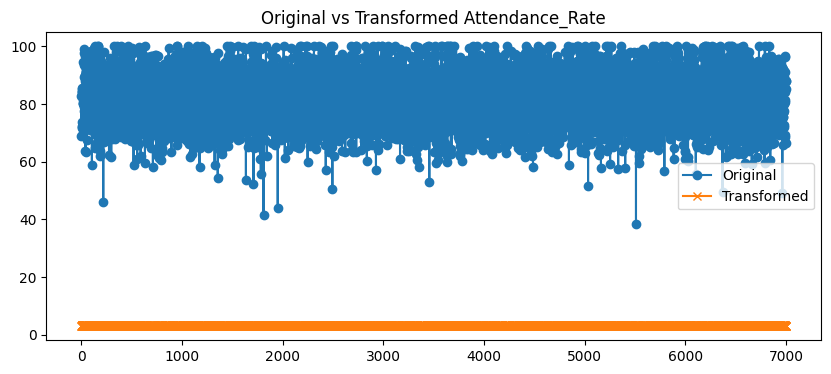

In [90]:
# Original Attendance_Rate
original = X_train_df['Attendance_Rate'].values
 
# Transformed Attendance_Rate
transformed = X_train_tdf['Attendance_Rate'].values
 
# 1. Check if all values are exactly equal
print("All values equal:", (original == transformed).all())
 
# 2. If not exactly equal, check maximum difference
print("Max difference:", np.max(np.abs(original - transformed)))
 
# 3. Quick visual check (optional)
plt.figure(figsize=(10,4))
plt.plot(original, label='Original', marker='o')
plt.plot(transformed, label='Transformed', marker='x')
plt.legend()
plt.title('Original vs Transformed Attendance_Rate')
plt.show()